In [ ]:
import glob
import pickle

from experiments.end_to_end.proof_node import ErrorNode, ProofFinishedNode
import torch
from torchmetrics.functional import pairwise_cosine_similarity

from transformers import AutoTokenizer, T5ForConditionalGeneration
from transformers import T5EncoderModel


In [ ]:


def get_tac_encodings(
        encoder, input_ids: torch.LongTensor, attention_mask: torch.LongTensor, tactic_lens
) -> torch.FloatTensor:
    # encode all tokens with tactic included
    combined_enc = encoder(input_ids, attention_mask, return_dict=True).last_hidden_state

    # get the tactic embeddings and mean pool them using the provided lengths
    tac_enc = []

    for i in range(combined_enc.shape[0]):
        enc = combined_enc[i, :tactic_lens[i]]
        enc = enc.sum(dim=0) / tactic_lens[i]
        enc = F.normalize(enc, dim=0)
        tac_enc.append(enc)

    tac_enc = torch.stack(tac_enc, dim=0).unsqueeze(1)
    return tac_enc


def get_vecs(encoder, tactics, goal, theorem):
    state = goal.data['augmented_state'] if hasattr(goal, 'data') and 'augmented_state' in goal.data else goal.goal

    encs = []

    for t in tactics:
        goal = [t + theorem + '\n\n' + state]

        tokenized_goals = tokenizer(
            goal,
            padding="longest",
            max_length=int(3000),
            truncation=True,
            return_tensors="pt", )

        tokenized_tactics = tokenizer(
            tactics,
            padding="longest",
            max_length=3000,
            truncation=True,
            return_tensors="pt",
        )

        lens = tokenized_tactics.attention_mask.sum(dim=1)

        enc = get_tac_encodings(encoder, tokenized_goals.input_ids.cuda(), tokenized_goals.attention_mask.cuda(),
                                lens.cuda())

        # scale enc by normalised tactic logprob
        # enc = enc * probs[tactics.index(t)]
        encs.append(enc.squeeze(0).squeeze(0))

    return torch.stack(encs, dim=0)


In [ ]:

import torch.nn.functional as F


def _encode(
        encoder, input_ids: torch.LongTensor, attention_mask: torch.LongTensor
) -> torch.FloatTensor:
    hidden_states = encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        return_dict=True,
    ).last_hidden_state

    # Masked average.
    lens = attention_mask.sum(dim=1)
    features = (hidden_states * attention_mask.unsqueeze(2)).sum(
        dim=1
    ) / lens.unsqueeze(1)

    # Normalize the feature vector to have unit norm.
    return F.normalize(features, dim=1)


In [ ]:

def plot(start, end, sims):
    # Convert the tensor to a NumPy array
    similarity_matrix_np = sims.cpu().detach().numpy()[start:end, start:end]

    names = tacs[start:end]
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np, xticklabels=names, yticklabels=names, annot=True, cmap='viridis')

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add labels and title
    plt.xlabel('Vectors')
    plt.ylabel('Vectors')
    plt.title('Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_overlay(start, end, sims1, sims2):
    # Convert the tensors to NumPy arrays
    similarity_matrix_np1 = sims1.cpu().detach().numpy()[start:end, start:end]
    similarity_matrix_np2 = sims2.cpu().detach().numpy()[start:end, start:end]

    names = tacs[start:end]

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(similarity_matrix_np1, xticklabels=names, yticklabels=names, annot=False, cmap='viridis',
                     cbar=False)
    sns.heatmap(similarity_matrix_np2, xticklabels=names, yticklabels=names, annot=False, cmap='viridis', cbar=True,
                ax=ax)

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add diagonal splits and annotations
    for i in range(len(names)):
        for j in range(len(names)):
            value1 = similarity_matrix_np1[i, j]
            value2 = similarity_matrix_np2[i, j]

            # Add diagonal line
            # ax.add_patch(patches.Polygon([(j, i), (j+1, i), (j, i+1)], closed=True, fill=True, color='blue', alpha=0.3))
            # ax.add_patch(patches.Polygon([(j+1, i), (j+1, i+1), (j, i+1)], closed=True, fill=True, color='red', alpha=0.3))

            ax.add_patch(patches.Polygon([(j, i), (j + 1, i), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value1), alpha=0.3))
            ax.add_patch(patches.Polygon([(j + 1, i), (j + 1, i + 1), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value2), alpha=0.3))
            # Add annotations
            ax.text(j + 0.25, i + 0.25, f'{value1:.2f}', ha='center', va='center', fontsize=8, color='white')
            ax.text(j + 0.75, i + 0.75, f'{value2:.2f}', ha='center', va='center', fontsize=8, color='white')

    # Add labels and title
    plt.xlabel('Tactic')
    plt.ylabel('Tactic')
    plt.title('Overlay Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.show()

# Example usage
# plot_overlay(start, end, sims1, sims2)


In [68]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_overlay_2(inds, sims1, sims2):
    # Convert the tensors to NumPy arrays
    similarity_matrix_np1 = sims1.cpu().detach().numpy()[inds][:, inds]
    similarity_matrix_np2 = sims2.cpu().detach().numpy()[inds][:, inds]

    print(similarity_matrix_np2)
    print(similarity_matrix_np2.shape)

    names = [(tacs[j], i) for i, j in enumerate(inds)]

    # Create the heatmap
    plt.figure(figsize=(5, 4))
    
    # ax = sns.heatmap(similarity_matrix_np1, xticklabels=names, yticklabels=names, annot=False, cmap='coolwarm',
    #                  cbar=False)
    # sns.heatmap(similarity_matrix_np2, xticklabels=names, yticklabels=names, annot=False, cmap='coolwarm', cbar=True,
    #             ax=ax)

    ax = sns.heatmap(similarity_matrix_np1, yticklabels=names, annot=False, cmap='seismic',
                     cbar=False)
    sns.heatmap(similarity_matrix_np2, yticklabels=names, annot=False, cmap='bwr', cbar=True,
                ax=ax)

    # Move x-axis labels to the top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Slant x-axis labels
    plt.xticks(rotation=45, ha='left')

    # Add diagonal splits and annotations
    for i in range(len(names)):
        for j in range(len(names)):
            value1 = similarity_matrix_np1[i, j]
            value2 = similarity_matrix_np2[i, j]

            # Add diagonal line
            # ax.add_patch(patches.Polygon([(j, i), (j+1, i), (j, i+1)], closed=True, fill=True, color='blue', alpha=0.3))
            # ax.add_patch(patches.Polygon([(j+1, i), (j+1, i+1), (j, i+1)], closed=True, fill=True, color='red', alpha=0.3))

            ax.add_patch(patches.Polygon([(j, i), (j + 1, i), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value1), alpha=0.3))
            ax.add_patch(patches.Polygon([(j + 1, i), (j + 1, i + 1), (j, i + 1)], closed=True, fill=True,
                                         facecolor=plt.cm.viridis(value2), alpha=0.3))
            # Add annotations
            ax.text(j + 0.25, i + 0.25, f'{value1:.2f}', ha='center', va='center', fontsize=8, color='white')
            ax.text(j + 0.75, i + 0.75, f'{value2:.2f}', ha='center', va='center', fontsize=8, color='white')

    # Add labels and title
    # plt.xlabel('Tactic')
    # plt.ylabel('Tactic')
    # plt.title('Overlay Pairwise Cosine Similarity Heatmap')

    # Display the heatmap
    plt.savefig('sim.pdf', bbox_inches='tight')
    plt.show()

# Example usage
# plot_overlay(start, end, sims1, sims2)


In [ ]:
# separate_encoder_path = '../runs/separate_tac_encoder/checkpoints/separate_last.ckpt'

autoenc_path = '../runs/diversity/autoencoder/2024_07_18/12_13/checkpoints/autoencoder.ckpt'

combined_error_path = '../runs/error_pred/combined_transition_model/combined_minif2f_valid.ckpt'

ckpt = torch.load(combined_error_path)
state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

error_encoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                               state_dict=state_dict).cuda()

# ckpt = torch.load(separate_encoder_path)
# state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}
# separate_encoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
#                                                   state_dict=state_dict).cuda()


ckpt = torch.load(autoenc_path)

state_dict = {k[12:]: v for k, v in ckpt.items() if k.startswith('tac_encoder')}

autoencoder = T5EncoderModel.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
                                             state_dict=state_dict).cuda()



In [ ]:

# state_dict = {k[8:]: v for k, v in ckpt.items() if k.startswith('decoder')}
# 
# autoenc_dec = T5ForConditionalGeneration.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises',
#                                                          state_dict=state_dict).cuda()
# 

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('sean-lamont/leandojo-lean3-reprover-novel-premises')


In [ ]:

score_network = torch.nn.Sequential(
    torch.nn.Linear(error_encoder.config.d_model, error_encoder.config.d_model // 2),
    torch.nn.LayerNorm(error_encoder.config.d_model // 2),
    torch.nn.ReLU(),
    torch.nn.Linear(error_encoder.config.d_model // 2, 2),
)

ckpt = torch.load(combined_error_path)
state_dict = {k[14:]: v for k, v in ckpt.items() if k.startswith('score_network')}

score_network.load_state_dict(state_dict)


In [ ]:
score_network.to('cuda')

In [ ]:

def get_total_sim(file):
    trace = pickle.load(open(file, 'rb'))
    nodes = list(trace.nodes.values())

    # 2
    node = nodes[0]
    tacs = [e.tactic for e in node.out_edges]
    theorem = trace.theorem.full_name

    with torch.no_grad():
        error_encs = get_vecs(error_encoder, tacs, node, theorem)
        tokenized_tacs = [tokenizer(e,
                                    padding="longest",
                                    max_length=2300,
                                    truncation=True,
                                    return_tensors="pt") for e in tacs]

        lens = [tokenized_tactic.attention_mask.sum(dim=1) for tokenized_tactic in tokenized_tacs]

        autoencs = [_encode(autoencoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]

        autoencs = torch.stack(autoencs)


    error_cosine_sim = pairwise_cosine_similarity(error_encs)
    autoencsim = pairwise_cosine_similarity(autoencs)

    unique_tactics = set()
    seen = set()
    for i, n in enumerate(node.out_edges):
        for sg in n.dst:
            if not isinstance(sg, ErrorNode) and not isinstance(sg, ProofFinishedNode):
                if sg.goal not in seen:
                    seen.add(sg.goal)
                    if n.tactic not in unique_tactics:
                        unique_tactics.add((i, n.tactic))
    # 
    autoenc_sim_total = []
    error_sim_total = []
    for i, v in enumerate(unique_tactics):
        # print (i, v)
        for j, x in enumerate(unique_tactics):
            error_sim_total.append(error_cosine_sim[v[0], x[0]].item())
            autoenc_sim_total.append(autoencsim[v[0], x[0]].item())
            
    if error_sim_total and autoenc_sim_total:
        
        print(sum(error_sim_total) / len(error_sim_total), sum(autoenc_sim_total) / len(autoenc_sim_total))
        
        return sum(error_sim_total) / len(error_sim_total), sum(autoenc_sim_total) / len(autoenc_sim_total)
    else:   
        return 0, 0


In [ ]:

from tqdm import tqdm
import glob

files = glob.glob('../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/*')

error_sims = []
autoenc_sims = []
for file in tqdm(files):
    e, a = get_total_sim(file)
    error_sims.append(e)
    autoenc_sims.append(a)
    print (sum(error_sims) / len(error_sims), sum(autoenc_sims) / len(autoenc_sims))
    
print (sum(error_sims) / len(error_sims), sum(autoenc_sims) / len(autoenc_sims))



    


In [ ]:
import matplotlib.pyplot as plt
# add opacity
plt.hist(error_sims, bins=20, alpha=0.5, label='Transition Model')
plt.hist(autoenc_sims, bins=20, alpha=0.5, label='Autoencoder')
# add title and labels
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
# xrange
plt.xlim(0.05, 0.85)
plt.legend()

# save to pdf
plt.savefig('sim_hist.pdf', bbox_inches='tight')

In [62]:

# good example with node 0
# test_trace = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/algebra_manipexpr_apbeq2cceqiacpbceqm2'

# good examples vs autoenc
# test_trace = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/mathd_algebra_422'
test_trace = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/mathd_numbertheory_403'

# test_trace = '../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/mathd_numbertheory_780'

# test_trace = "../runs/bestfs-novel-2/cau_seq.lim_inv"


trace = pickle.load(open(test_trace, 'rb'))
nodes = list(trace.nodes.values())

# 2
node = nodes[0]
tacs = [e.tactic for e in node.out_edges]
theorem = trace.theorem.full_name

with torch.no_grad():
    error_encs = get_vecs(error_encoder, tacs, node, theorem)
    tokenized_tacs = [tokenizer(e,
                                padding="longest",
                                max_length=2300,
                                truncation=True,
                                return_tensors="pt") for e in tacs]

    lens = [tokenized_tactic.attention_mask.sum(dim=1) for tokenized_tactic in tokenized_tacs]

    # vecs = [_encode(separate_encoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]
    # separate_encs = torch.stack(vecs)

    autoencs = [_encode(autoencoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]

    autoencs = torch.stack(autoencs)

# separate_cosine_sim = pairwise_cosine_similarity(separate_encs)


error_cosine_sim = pairwise_cosine_similarity(error_encs)
autoencsim = pairwise_cosine_similarity(autoencs)

for i, e in enumerate(node.out_edges):
    print(i, e)

unique_tactics = set()
seen = set()
for i, n in enumerate(node.out_edges):
    for sg in n.dst:
        if not isinstance(sg, ErrorNode) and not isinstance(sg, ProofFinishedNode):
            if sg.goal not in seen:
                seen.add(sg.goal)
                if n.tactic not in unique_tactics:
                    unique_tactics.add((i, n.tactic))
# 
autoenc_sim_total = []
error_sim_total = []
for i, v in enumerate(unique_tactics):
    # print (i, v)
    for j, x in enumerate(unique_tactics):
        error_sim_total.append(error_cosine_sim[v[0], x[0]].item())
        autoenc_sim_total.append(autoencsim[v[0], x[0]].item())
        
print(sum(error_sim_total) / len(error_sim_total), sum(autoenc_sim_total) / len(autoenc_sim_total))


0 Edge(tactic='simp', tac_logprob=-1.2183305025100708, goal_logprob=0.0, time=2.145622312091291)
1 Edge(tactic='simp [<a>nat.proper_divisors</a>]', tac_logprob=-2.7750701904296875, goal_logprob=0.0, time=5.615530506009236)
2 Edge(tactic='norm_num1', tac_logprob=-3.849942684173584, goal_logprob=0.0, time=0.9795445950003341)
3 Edge(tactic='norm_num', tac_logprob=-4.028590202331543, goal_logprob=0.0, time=1.2950297460192814)
4 Edge(tactic='simp [<a>nat.sum_proper_divisors</a>]', tac_logprob=-4.246223449707031, goal_logprob=0.0, time=1.0992048939224333)
5 Edge(tactic='rw <a>nat.sum_proper_divisors_eq_one_iff_prime</a>', tac_logprob=-4.31151819229126, goal_logprob=0.0, time=1.0013090070569888)
6 Edge(tactic='simp [<a>nat.sum_proper_divisors_eq_one_iff_prime</a>]', tac_logprob=-4.649013996124268, goal_logprob=0.0, time=1.5042677549645305)
7 Edge(tactic='dec_trivial', tac_logprob=-4.954667568206787, goal_logprob=0.0, time=5.49462307500653)
8 Edge(tactic='classical', tac_logprob=-5.21437215805

[[0.         0.94253385 0.55097026 0.8128614  0.41866544 0.50778854]
 [0.94253385 0.         0.57567763 0.811511   0.4757468  0.53324556]
 [0.55097026 0.57567763 0.         0.6458603  0.737028   0.78704906]
 [0.8128614  0.811511   0.6458603  0.         0.5119643  0.55372065]
 [0.41866544 0.4757468  0.737028   0.5119643  0.         0.77277887]
 [0.50778854 0.53324556 0.78704906 0.55372065 0.77277887 0.        ]]
(6, 6)


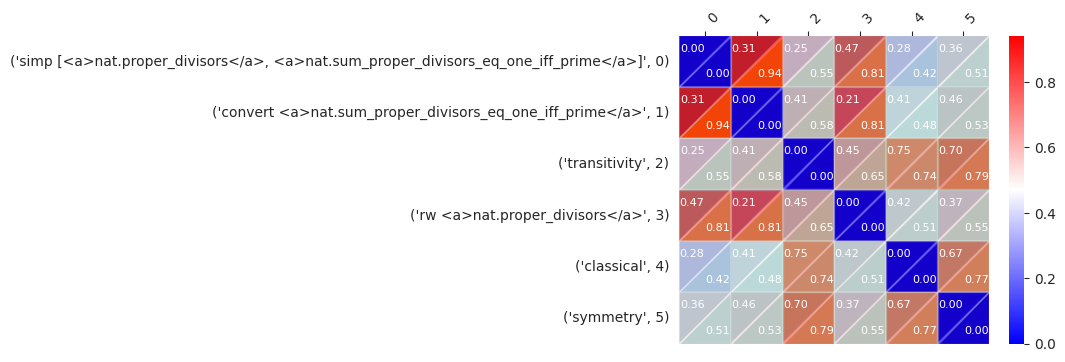

In [69]:

# inds = [0, 12, 30, 45, 7]
# inds = [x[0] for a in list(subgoals.values()) for x in a]
inds = [t[0] for t in unique_tactics]

names = [tacs[i] for i in inds]
gt = [node.out_edges[i] for i in inds]

plot_overlay_2(inds, error_cosine_sim, autoencsim)

In [ ]:
# scores = score_network(error_encs)
# 
# error_preds = torch.sigmoid(scores[:, 0])
# time_scores = scores[:, 1]
# 
# # normalise time scores
# 
# time_scores = F.normalize(time_scores, dim=-1, p=2)
# time_scores = 1 - time_scores


# time_scores

In [ ]:
from experiments.end_to_end.proof_node import ErrorNode

start = 0
end = 16

names = tacs[start:end]
gt = node.out_edges[start:end]

# for x in [(i + start, names[i], round(error_preds[i].item(),2), 0 if type(gt[i].dst[0]) == ErrorNode else 1, time_scores[i].item(), gt[i].time, ) for i in range(len(names))]:
#     print (x)

# print (node.data['augmented_state'])
plot_overlay(start, end, error_cosine_sim, autoencsim)
# plot_overlay(start, end, error_cosine_sim, time_scores.unsqueeze(1))


# plot_overlay(start, end, autoencsim, combined_cosine_sim)

In [ ]:
# from tqdm import tqdm
# import glob
# 
# files = glob.glob('../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/*')
# for file in tqdm(files):
#     trace = pickle.load(open(file, 'rb'))
#     nodes = list(trace.nodes.values())
#     if not nodes:
#         continue
#     node = nodes[0]
#     tacs = [e.tactic for e in node.out_edges]
#     theorem = trace.theorem.full_name
# 
#     with torch.no_grad():
#         error_encs = get_vecs(error_encoder, tacs, node, theorem)
#         tokenized_tacs = [tokenizer(e,
#                                     padding="longest",
#                                     max_length=2300,
#                                     truncation=True,
#                                     return_tensors="pt") for e in tacs]
# 
#         lens = [tokenized_tactic.attention_mask.sum(dim=1) for tokenized_tactic in tokenized_tacs]
# 
#         autoencs = [_encode(autoencoder, tac.input_ids.cuda(), tac.attention_mask.cuda())[0] for tac in tokenized_tacs]
# 
#         autoencs = torch.stack(autoencs)
# 
# 
# 
#     error_cosine_sim = pairwise_cosine_similarity(error_encs)
#     autoencsim = pairwise_cosine_similarity(autoencs)
# 
# 
#     # time_scores
#     subgoals = {}
#     for i, n in enumerate(node.out_edges):
#         for sg in n.dst:
#             if not isinstance(sg, ErrorNode) and not isinstance(sg, ProofFinishedNode):
#                 if sg not in subgoals:
#                     subgoals[sg] = [(i, n.tactic)]
#                 else:
#                     subgoals[sg].append((i, n.tactic))
# 
#             elif isinstance(sg, ErrorNode):
#                 if sg.inner.message not in subgoals:
#                     subgoals[sg.inner.message] = [(i, n.tactic)]
#                 else:
#                     subgoals[sg.inner.message].append((i, n.tactic))
# 
#     autoenc_sim_total = []
#     error_sim_total = []
#     for k, v in subgoals.items():
#         for i, x in enumerate(v):
#             for j in range(i + 1, len(v)):
#                 autoenc_sim_total.append(autoencsim[v[i][0], v[j][0]].item())
#                 error_sim_total.append(error_cosine_sim[v[i][0], v[j][0]].item())
# 
#     autoenc_sim_total = sum(autoenc_sim_total) / len(autoenc_sim_total)
#     error_sim_total = sum(error_sim_total) / len(error_sim_total)
# 
#     print(autoenc_sim_total, error_sim_total)
# 

# elif isinstance(sg, ErrorNode):
#     if sg.inner.message not in seen:
#         seen.add(sg.inner.message)
#         if n.tactic not in unique_tactics:
#             unique_tactics.add((i, n.tactic))

# elif isinstance(sg, ErrorNode):
#     unique_tactics.add(sg.inner.message)

# (if goal leads to two different subgoals, if one is the same then can mess this comparison up)
# subgoals = {}
# 
# for i, n in enumerate(node.out_edges):
#     for sg in n.dst:
#         print (i, n)
#         if not isinstance(sg, ErrorNode) and not isinstance(sg, ProofFinishedNode):
#             if sg.goal not in subgoals:
#                 subgoals[sg.goal] = [(i, n.tactic)]
#             else:
#                 subgoals[sg.goal].append((i, n.tactic))
# 
#         # elif isinstance(sg, ErrorNode):
#         #     if sg.inner.message not in subgoals:
#         #         subgoals[sg.inner.message] = [(i, n.tactic)]
#         #     else:
#         #         subgoals[sg.inner.message].append((i, n.tactic))
